# Capture IQ from Pluto Plus

In [7]:
import numpy as np
import adi
import time

def pluto_capture_iq(
    uri="ip:pluto.local",
    center_hz=2.4065e9,
    sample_rate=2_300_000,
    rf_bandwidth=1_000_000,
    gain_mode="manual",        # "manual" or "slow_attack"
    gain_db=8,
    num_samples=2_300_000,     # 1 second at 2.3 MS/s
    warmup_reads=2,
):
    """
    Returns complex64 IQ array of length num_samples (approximately).
    """
    sdr = adi.Pluto(uri)

    # RX configuration
    sdr.rx_lo = int(center_hz)
    sdr.sample_rate = int(sample_rate)
    sdr.rx_rf_bandwidth = int(rf_bandwidth)

    sdr.gain_control_mode_chan0 = gain_mode
    if gain_mode == "manual":
        sdr.rx_hardwaregain_chan0 = float(gain_db)

    # Buffering
    # rx_buffer_size controls how many samples you get per read().
    # Using a moderate chunk size is reliable.
    chunk = 262144
    sdr.rx_buffer_size = chunk

    # Warm up (let LO/filters settle)
    for _ in range(warmup_reads):
        _ = sdr.rx()

    # Capture in chunks
    iq = np.empty(num_samples, dtype=np.complex64)
    got = 0
    while got < num_samples:
        x = sdr.rx().astype(np.complex64)
        n = min(len(x), num_samples - got)
        iq[got:got+n] = x[:n]
        got += n

    return iq


In [8]:
Fs = 2_300_000
iq = pluto_capture_iq(
    uri="ip:pluto.local",
    center_hz=2.4065e9,
    sample_rate=Fs,
    rf_bandwidth=1_000_000,
    gain_mode="manual",
    gain_db=8,
    num_samples=Fs * 2,   # 2 seconds
)
print(iq.shape, iq.dtype)


(4600000,) complex64


In [5]:
import matplotlib.pyplot as plt

def quick_mag_plot(iq, Fs, seconds=0.05):
    n = int(Fs * seconds)
    m = np.abs(iq[:n])
    t = np.arange(len(m)) / Fs
    plt.figure()
    plt.plot(t*1e3, m)
    plt.xlabel("Time (ms)")
    plt.ylabel("|IQ|")
    plt.show()


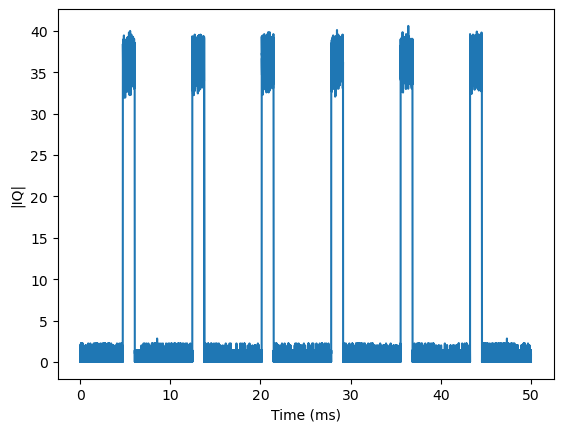

In [15]:
quick_mag_plot(iq, Fs, seconds=0.05)

In [10]:
import numpy as np
from dataclasses import dataclass

try:
    from scipy.signal import firwin, lfilter, resample_poly
except ImportError as e:
    raise ImportError("This notebook needs scipy (scipy.signal). Install it or tell me to provide a pure-numpy version.") from e

@dataclass
class Burst:
    start: int
    end: int

def fm_discriminator(x: np.ndarray) -> np.ndarray:
    """
    Quadrature discriminator: returns phase difference per sample (radians/sample).
    """
    x1 = x[1:]
    x0 = x[:-1]
    return np.angle(np.conj(x0) * x1)

def lowpass_fir(y: np.ndarray, fs: float, cutoff_hz: float, numtaps: int = 129) -> np.ndarray:
    taps = firwin(numtaps, cutoff_hz/(fs/2))
    return lfilter(taps, 1.0, y)

def detect_bursts(x: np.ndarray, fs: float, thresh_db: float = -20.0,
                  min_len_ms: float = 0.5, pad_ms: float = 0.2) -> list[Burst]:
    """
    Simple magnitude-based burst detector.
    thresh_db is relative to median magnitude.
    """
    mag = np.abs(x)
    med = np.median(mag)
    thr = med * (10**(thresh_db/20.0))

    above = mag > thr
    # Find contiguous regions above threshold
    idx = np.flatnonzero(above)
    if idx.size == 0:
        return []

    # Split into runs
    splits = np.where(np.diff(idx) > 1)[0] + 1
    runs = np.split(idx, splits)

    min_len = int((min_len_ms/1000.0) * fs)
    pad = int((pad_ms/1000.0) * fs)

    bursts = []
    for r in runs:
        if r.size < min_len:
            continue
        s = max(0, r[0]-pad)
        e = min(len(x)-1, r[-1]+pad)
        bursts.append(Burst(s, e))
    return bursts

def pick_best_symbol_phase(sym: np.ndarray, sps: int) -> tuple[int, float, float]:
    """
    Pick phase offset that produces the most bimodal samples.
    Returns (best_phase, threshold, score).
    """
    best_phase = 0
    best_score = -1
    best_thr = 0.0

    for ph in range(sps):
        z = sym[ph::sps]
        if z.size < 50:
            continue
        # robust threshold: median
        thr = np.median(z)
        b0 = z[z <= thr]
        b1 = z[z > thr]
        if b0.size < 10 or b1.size < 10:
            continue
        m0, m1 = np.mean(b0), np.mean(b1)
        v0, v1 = np.var(b0), np.var(b1)
        # score: separation / within-class variance
        score = (abs(m1-m0) / (np.sqrt(v0+v1) + 1e-9))
        if score > best_score:
            best_score = score
            best_phase = ph
            best_thr = thr

    return best_phase, best_thr, best_score

def slice_bits(sym: np.ndarray, sps: int, phase: int, thr: float) -> np.ndarray:
    z = sym[phase::sps]
    bits = (z > thr).astype(np.uint8)
    return bits

def bits_to_bytes(bits: np.ndarray, msb_first: bool = True) -> bytes:
    n = (len(bits)//8)*8
    b = bits[:n].reshape(-1, 8)
    if msb_first:
        vals = (b * (1 << np.arange(7, -1, -1))).sum(axis=1)
    else:
        vals = (b * (1 << np.arange(0, 8))).sum(axis=1)
    return bytes(vals.tolist())


In [11]:
def demod_bursts_to_hex(iq: np.ndarray, Fs: float, symrate: float = 500e3,
                        target_sps: int = 4, lp_cutoff_hz: float = 300e3):
    """
    Returns list of dicts with burst info and decoded byte strings (both bit orders).
    """
    bursts = detect_bursts(iq, Fs, thresh_db=-18, min_len_ms=0.6, pad_ms=0.2)
    print(f"Detected {len(bursts)} bursts")

    out = []
    for i, b in enumerate(bursts):
        x = iq[b.start:b.end]

        # Discriminator (radians/sample at Fs)
        dphi = fm_discriminator(x)

        # Lowpass to suppress noise and high-frequency crap
        dphi_f = lowpass_fir(dphi, Fs, cutoff_hz=lp_cutoff_hz, numtaps=129)

        # Resample to integer sps
        # We want Fs_rs = symrate * target_sps
        Fs_rs = symrate * target_sps
        # Use rational resampling
        up = int(round(Fs_rs/1e3))
        dn = int(round(Fs/1e3))
        # reduce fraction
        g = np.gcd(up, dn)
        up //= g; dn //= g

        dphi_rs = resample_poly(dphi_f, up, dn)

        # Pick best symbol phase + threshold
        ph, thr, score = pick_best_symbol_phase(dphi_rs, target_sps)
        bits = slice_bits(dphi_rs, target_sps, ph, thr)

        # Convert to bytes in both bit orders (we don't know yet)
        bb_msb = bits_to_bytes(bits, msb_first=True)
        bb_lsb = bits_to_bytes(bits, msb_first=False)

        out.append({
            "burst_index": i,
            "start_s": b.start/Fs,
            "len_s": (b.end-b.start)/Fs,
            "score": score,
            "phase": ph,
            "thr": float(thr),
            "bits_len": int(len(bits)),
            "hex_msb": bb_msb.hex(),
            "hex_lsb": bb_lsb.hex(),
        })
    return out


In [104]:
# Example:
# Fs_capture = 2.3e6
# iq = ... (np.complex64 array)
frames = demod_bursts_to_hex(iq, Fs, symrate=500e3, target_sps=4, lp_cutoff_hz=250e3)
frames[:2]


Detected 260 bursts


[{'burst_index': 0,
  'start_s': np.float64(0.004544782608695652),
  'len_s': np.float64(0.0017143478260869566),
  'score': np.float64(2.8808981077578446),
  'phase': 0,
  'thr': 0.15610453460379253,
  'bits_len': 857,
  'hex_msb': '00008291cb5a40160c2c171833d6c0000000555555555475c52ab18b174c4e8b000003fffffffffffffc00b0001d313ab18f48b15396160270059393e9589cb1d622c5e22dd22e262e800b0003fffffffffffffffffffffffffffc0002da7a7fdb156900838ceb6f1c082f',
  'hex_lsb': '00004189d35a02683034e818cc6b03000000aaaaaaaa2aaea3548dd1e83272d10000c0ffffffffffff3f000d00b88c5c8df1128dca6968400ea0c9c9971a398d6b44a347b44b74647401d000c0ffffffffffffffffffffffffff3f00405b5efedba89600c131d7f63810f4'},
 {'burst_index': 1,
  'start_s': np.float64(0.012243913043478261),
  'len_s': np.float64(0.0017139130434782608),
  'score': np.float64(3.1426792644781365),
  'phase': 2,
  'thr': 0.05538577342449557,
  'bits_len': 857,
  'hex_msb': '00001cc763b0db6847be2b1b56cda0000000555555555475c52ab18b174c4e8b000003fffffffffffffc0

In [14]:
def hex_to_bytes(h: str) -> np.ndarray:
    return np.frombuffer(bytes.fromhex(h), dtype=np.uint8)

def hamming_bytes(a: np.ndarray, b: np.ndarray) -> int:
    n = min(len(a), len(b))
    return int(np.count_nonzero(a[:n] != b[:n])) + abs(len(a)-len(b))

def compare_frames(frames, use="hex_msb", max_show=10):
    arr = [hex_to_bytes(f[use]) for f in frames]
    # compare to first frame
    base = arr[0]
    dists = [hamming_bytes(base, x) for x in arr]
    order = np.argsort(dists)
    for k in order[:max_show]:
        print(f"frame {k:03d}  dist={dists[k]:4d}  len={len(arr[k])} bytes  score={frames[k]['score']:.2f}")

def bytewise_diff(a: bytes, b: bytes):
    aa = np.frombuffer(a, dtype=np.uint8)
    bb = np.frombuffer(b, dtype=np.uint8)
    n = min(len(aa), len(bb))
    diff = np.where(aa[:n] != bb[:n])[0]
    return diff, aa, bb


In [97]:
import numpy as np

def longest_alternating_segment(bits):
    b = np.fromiter(bits, dtype=np.uint8) - ord('0')
    alt = (b[1:] != b[:-1])

    idx = np.flatnonzero(alt)
    if len(idx) == 0:
        return None

    runs = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1)
    best = max(runs, key=len)

    # transitions at positions best[0]..best[-1] correspond to bits best[0]..best[-1]+1
    start = int(best[0])
    end = int(best[-1] + 1)
    return {
        "start": start,
        "end": end,
        "transition_len": int(len(best)),
        "bit_len": int(len(best) + 1),
        "snippet": bits[start:end+1],  # small preview
    }


In [98]:
for i in range(50):
    hex_num = frames[i]["hex_msb"]
    bits = format(int(hex_num, 16), 'b')

    info = longest_alternating_segment(bits)
    print(info)

{'start': 128, 'end': 166, 'transition_len': 38, 'bit_len': 39, 'snippet': '010101010101010101010101010101010101010'}
{'start': 125, 'end': 163, 'transition_len': 38, 'bit_len': 39, 'snippet': '010101010101010101010101010101010101010'}
{'start': 129, 'end': 167, 'transition_len': 38, 'bit_len': 39, 'snippet': '010101010101010101010101010101010101010'}
{'start': 127, 'end': 165, 'transition_len': 38, 'bit_len': 39, 'snippet': '010101010101010101010101010101010101010'}
{'start': 131, 'end': 169, 'transition_len': 38, 'bit_len': 39, 'snippet': '010101010101010101010101010101010101010'}
{'start': 131, 'end': 169, 'transition_len': 38, 'bit_len': 39, 'snippet': '010101010101010101010101010101010101010'}
{'start': 128, 'end': 166, 'transition_len': 38, 'bit_len': 39, 'snippet': '010101010101010101010101010101010101010'}
{'start': 131, 'end': 169, 'transition_len': 38, 'bit_len': 39, 'snippet': '010101010101010101010101010101010101010'}
{'start': 131, 'end': 169, 'transition_len': 38, 'bit_le

In [99]:
def first_long_constant_run(bits, start=0, run_len=64):
    cur = bits[start]
    streak = 1
    for i in range(start+1, len(bits)):
        if bits[i] == cur:
            streak += 1
            if streak >= run_len:
                return i - streak + 1, i, cur  # (run_start, run_end, bit)
        else:
            cur = bits[i]
            streak = 1
    return None


In [100]:
first_long_constant_run(bits, start=0, run_len=64)

(601, 664, '1')

In [101]:
frames[0]

{'burst_index': 0,
 'start_s': np.float64(0.004544782608695652),
 'len_s': np.float64(0.0017143478260869566),
 'score': np.float64(2.8808981077578446),
 'phase': 0,
 'thr': 0.15610453460379253,
 'bits_len': 857,
 'hex_msb': '00008291cb5a40160c2c171833d6c0000000555555555475c52ab18b174c4e8b000003fffffffffffffc00b0001d313ab18f48b15396160270059393e9589cb1d622c5e22dd22e262e800b0003fffffffffffffffffffffffffffc0002da7a7fdb156900838ceb6f1c082f',
 'hex_lsb': '00004189d35a02683034e818cc6b03000000aaaaaaaa2aaea3548dd1e83272d10000c0ffffffffffff3f000d00b88c5c8df1128dca6968400ea0c9c9971a398d6b44a347b44b74647401d000c0ffffffffffffffffffffffffff3f00405b5efedba89600c131d7f63810f4'}

In [102]:
import numpy as np

def find_preamble(bits, min_alt_bits=32):
    b = np.fromiter(bits, dtype=np.uint8) - ord('0')
    alt = (b[1:] != b[:-1])
    idx = np.flatnonzero(alt)
    if len(idx) == 0:
        return None
    runs = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1)
    best = max(runs, key=len)
    start = int(best[0])
    end = int(best[-1] + 1)   # inclusive end of alternating-bit segment
    bit_len = len(best) + 1
    if bit_len < min_alt_bits:
        return None
    return start, end

def canonicalize_preamble(bits, start, end):
    s = start
    while s > 0 and bits[s] != bits[s-1]:
        s -= 1
    e = end
    while e+1 < len(bits) and bits[e] != bits[e+1]:
        e += 1
    return s, e

def first_long_constant_run(bits, start=0, run_len=64):
    cur = bits[start]
    streak = 1
    for i in range(start+1, len(bits)):
        if bits[i] == cur:
            streak += 1
            if streak >= run_len:
                return i - streak + 1, i, cur
        else:
            cur = bits[i]
            streak = 1
    return None

def extract_useful_window(bits, min_alt_bits=32, flat_run_len=64, after_preamble_offset=0):
    pre = find_preamble(bits, min_alt_bits=min_alt_bits)
    if pre is None:
        return None
    ps, pe = canonicalize_preamble(bits, pre[0], pre[1])

    # search for padding after the preamble (+ optional offset to skip sync word)
    search_start = pe + 1 + after_preamble_offset
    pad = first_long_constant_run(bits, start=search_start, run_len=flat_run_len)

    if pad is None:
        # no obvious padding; take rest
        data_end = len(bits)
    else:
        data_end = pad[0]  # start of long flat run

    return {
        "preamble_start": ps,
        "preamble_end": pe,
        "data_start": pe + 1,
        "data_end": data_end,
        "data_bits": bits[pe+1:data_end],
        "pad_run": pad
    }


In [147]:
import pprint

data_frames = []
for i in range(10):
    hex_num = frames[i]["hex_msb"]
    bits = format(int(hex_num, 16), 'b')
    out = extract_useful_window(bits)
    #pprint.pp(out)
    #print(len(out['data_bits']))
    print(hex(int(out['data_bits'], 2)))
    data_frames.append(hex(int(out['data_bits'], 2)))

0x1d714aac62c5d313a2c00000ffffffffffffff002c00074c4eac63d22c54e585809c0164e4fa56272c7588b1788b748b898ba002c000
0x1d714aac62c5d313a2c00000ffffffffffffff000000074c4eac63d22c54e585809c0164e4fa56272c7588b1788b748b898ba002c000
0x1d714aac58c5d313a2c00000ffffffffffffff002c00074c4eac63d22c54e585809c0164e4fa56272c7588b1788b748b898ba002c000
0x1d714aac62c5d313a2c00000ffffffffffffff002c00074c4eac63d22c54e585809c0164e4fa56272c7588b1788b748b898ba002c000
0x1d714aac62c5d313a2c00000ffffffffffffff000000074c4eac63d22c54e585809c0164e4fa56272c7588b1788b748b898ba002c000
0x1d714aac58c5d313a2c00000ffffffffffffff002c00074c4eac63d22c54e585809c0164e4fa56272c7588b1788b748b898ba002c000
0x1d714aac62c5d313a2c00000ffffffffffffff002c00074c4eac63d22c54e585809c0164e4fa56272c7588b1788b748b898ba002c000
0x1d714aac62c5d313a2c00000ffffffffffffff000000074c4eac63d22c54e585809c0164e4fa56272c7588b1788b748b898ba002c000
0x1d714aac58c5d313a2c00000ffffffffffffff002c00074c4eac63d22c54e585809c0164e4fa56272c7588b1788b748b898ba002c000
0

Per the observed format for bind beacons:

### [ID][TxID 4][RxID 4][Seq 2][ChanList 16] → 27 bytes

In [148]:
val = data_frames[0][2:]
print(val[:2])
print(val[2:10])
print(val[10:18])
print(val[18:22])
print(val[22:38])

1d
714aac62
c5d313a2
c000
00ffffffffffffff


In [149]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional


@dataclass(frozen=True)
class BindPacket:
    pkt_id: int          # 1 byte
    tx_id: bytes         # 4 bytes
    rx_id: bytes         # 4 bytes
    seq: bytes           # 2 bytes
    chan_list: bytes     # 16 bytes

    def as_dict(self):
        return {
            "ID": f"0x{self.pkt_id:02x}",
            "TxID": self.tx_id.hex(),
            "RxID": self.rx_id.hex(),
            "Seq": self.seq.hex(),
            "ChanList": self.chan_list.hex(" "),
        }


def hex_to_bytes(hex_str: str) -> bytes:
    s = hex_str.strip().lower()
    if s.startswith("0x"):
        s = s[2:]
    if len(s) % 2:
        # If you ever get an odd nibble count, this prevents ValueError.
        # If that happens frequently, it likely indicates upstream slicing issues.
        s = "0" + s
    return bytes.fromhex(s)


def parse_bind_packet_from_stream(
    stream: bytes,
    *,
    rxid_anchor: bytes = b"\xff\xff\xff\xff",
) -> Optional[BindPacket]:
    """
    Parse a bind packet with the logical structure:
      [ID][TxID 4][RxID 4][Seq 2][ChanList 16]  => 27 bytes

    This function assumes your 'stream' contains those 27 bytes somewhere,
    and uses RxID=FFFFFFFF as an anchor (matches 'dumb' FS-GT2E bind packets).

    Returns the first plausible match, or None.
    """
    i = 0
    while True:
        i = stream.find(rxid_anchor, i)
        if i < 0:
            return None

        # Layout relative to the start of RxID:
        # core_start = ID + TxID (5 bytes) before RxID
        core_start = i - (1 + 4)
        core_end = i + 4 + 2 + 16  # RxID + Seq + ChanList

        if core_start >= 0 and core_end <= len(stream):
            core = stream[core_start:core_end]  # 27 bytes

            pkt_id = core[0]
            tx_id = core[1:5]
            rx_id = core[5:9]
            seq = core[9:11]
            chan_list = core[11:27]

            return BindPacket(pkt_id=pkt_id, tx_id=tx_id, rx_id=rx_id, seq=seq, chan_list=chan_list)

        i += 1  # keep searching


# ----- Example usage on your sample -----
#hex_frame = "0x1d714aac62c5d313a2c00000ffffffffffffff002c00074c4eac63d22c54e585809c0164e4fa56272c7588b1788b748b898ba002c000"
hex_frame = data_frames[0]
b = hex_to_bytes(hex_frame)

pkt = parse_bind_packet_from_stream(b)
print("Total bytes in capture:", len(b))
if pkt is None:
    print("No bind packet found (RxID anchor not found or not enough bytes around it).")
else:
    pprint.pp(pkt.as_dict())


Total bytes in capture: 54
{'ID': '0x13',
 'TxID': 'a2c00000',
 'RxID': 'ffffffff',
 'Seq': 'ffff',
 'ChanList': 'ff 00 2c 00 07 4c 4e ac 63 d2 2c 54 e5 85 80 9c'}


In [152]:
def hex_to_bytes(h):
    h = h.strip().lower()
    if h.startswith("0x"):
        h = h[2:]
    # if odd length, pad on the left (or raise) – pick one strategy
    if len(h) % 2 == 1:
        h = "0" + h
    return bytes.fromhex(h)

# frames = [
#     "0x1d714aac62c5d313a2c00000ffffffffffffff002c00074c4eac63d22c54e585809c0164e4fa56272c7588b1788b748b898ba002c000",
#     "0x1d714aac62c5d313a2c00000ffffffffffffff000000074c4eac63d22c54e585809c0164e4fa56272c7588b1788b748b898ba002c000",
#     "0x1d714aac58c5d313a2c00000ffffffffffffff002c00074c4eac63d22c54e585809c0164e4fa56272c7588b1788b748b898ba002c000",
#     # ... add the rest ...
# ]

bs = [hex_to_bytes(x) for x in data_frames]
L = min(len(x) for x in bs)

vary = []
for i in range(L):
    vals = {b[i] for b in bs}
    if len(vals) > 1:
        vary.append((i, sorted(vals)))

print("min length:", L)
print("varying byte positions:")
for i, vals in vary:
    print(i, [f"{v:02x}" for v in vals])


min length: 54
varying byte positions:
4 ['58', '62']
20 ['00', '2c']


In [111]:
VOLATILE = {4, 20}   # from your diff

def normalize_frame(b: bytes) -> bytes:
    b = bytearray(b[:54])
    for i in VOLATILE:
        b[i] = 0x00
    return bytes(b)

# Example: cluster frames by their normalized content
from collections import Counter
counts = Counter(normalize_frame(x) for x in frames_bytes)
print("unique normalized frames:", len(counts))


NameError: name 'frames_bytes' is not defined

In [92]:
import pprint

for i in range(10):
    hex_num = frames[i]["hex_lsb"]
    bits = format(int(hex_num, 16), 'b')
    out = extract_useful_window(bits)
    #pprint.pp(out)
    #print(len(out['data_bits']))
    print(hex(int(out['data_bits'], 2)))

0x2aaea3548dd1e83272d10000c0ffffffffffff3f000d00b88c5c8df1128dca6968400ea0c9c9971a398d6b44a347b44b74647401d000c0
0x2aaea3548dd1e83272d10000c0ffffffffffff3f000000b88c5c8df1128dca6968400ea0c9c9971a398d6b44a347b44b74647401d000c0
0x2aaea3548dc6e83272d10000c0ffffffffffff3f000d00b88c5c8df1128dca6968400ea0c9c9971a398d6b44a347b44b74647401d000c0
0x2aaea3548dd1e83272d10000c0ffffffffffff3f000d00b88c5c8df1128dca6968400ea0c9c9971a398d6b44a347b44b74647401d000c0
0xc47a91aa3d165e4a2010080ffffffffffff7f0000007019b91ae3251a95d3d0801c4093932f35721ad788468f6897e8c8e802a00180
0x2aaea3548dc6e83272d10000c0ffffffffffff3f000d00b88c5c8df1128dca6968400ea0c9c9971a398d6b44a347b44b74647401d000c0
0x2aaea3548dd1e83272d10000c0ffffffffffff3f000d00b88c5c8df1128dca6968400ea0c9c9971a398d6b44a347b44b74647401d000c0
0x2aaea3548dd1e83272d10000c0ffffffffffff3f000000b88c5c8df1128dca6968400ea0c9c9971a398d6b44a347b44b74647401d000c0
0x2aaea3548dc6e83272d10000c0ffffffffffff3f000d00b88c5c8df1128dca6968400ea0c9c9971a398d6b44a347b44b7

In [80]:
len(out['data_bits'])

431

In [81]:
out['data_end'] - out['data_start']

431

In [83]:
pprint.pp(out)

{'preamble_start': 131,
 'preamble_end': 169,
 'data_start': 170,
 'data_end': 601,
 'data_bits': '00111010111000101001010101011000110001011000101110100110001001110100010110000000000000000000000111111111111111111111111111111111111111111111111111111110000000000000000000000000000011101001100010011101010110001100011110100100010110001010100111001011000010110000000100111000000000101100100111001001111101001010110001001110010110001110101100010001011000101111000100010110111010010001011100010011000101110100000000000101100000000000000',
 'pad_run': (601, 664, '1')}


In [88]:
print(hex(int(out['data_bits'], 2)))

0x1d714aac62c5d313a2c00000ffffffffffffff002c00074c4eac63d22c54e585809c0164e4fa56272c7588b1788b748b898ba002c000


In [ ]:
for i in range(50):
    hex_num = frames[i]["hex_msb"]
    bits = format(int(hex_num, 16), 'b')

    info = longest_alternating_segment(bits)
    print(info)